# SCRUM-5: Build Product Registry & Source Log

**Task:** Collect the actual dataset by defining the target products and documenting exactly where each data source came from and how it was collected.

**Assignee:** Burra Vijay Krishna | **Sprint:** SCRUM Sprint 0

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = os.path.join('..', 'data')
print('Setup complete.')

Setup complete.


## 1. Product Registry — Loading & Inspection

In [2]:
products = pd.read_csv(os.path.join(DATA_DIR, 'products.csv'))

print(f'Total products in registry: {len(products)}')
print(f'Columns: {list(products.columns)}')
print(f'Unique brands: {products["brand"].nunique()}')
print(f'Category: {products["category"].unique()[0]}')
print()
products.head(10)

Total products in registry: 60
Columns: ['product_id', 'product_name', 'brand', 'category', 'trends_query', 'youtube_query', 'launch_period', 'product_type', 'notes']
Unique brands: 13
Category: Smartphones



,product_id,product_name,brand,category,trends_query,youtube_query,launch_period,product_type,notes
0,P001,Apple iPhone 18 Pro,Apple,Smartphones,iphone 18 pro,iphone 18 pro review,2026-09,RISING,Trends query also matches iphone 18 pro max se...
1,P002,Apple iPhone 18 Pro Max,Apple,Smartphones,iphone 18 pro max,iphone 18 pro max review,2026-09,RISING,India sale from 2026-09-18
2,P003,Apple iPhone Duo,Apple,Smartphones,iphone duo,iphone duo review,2026-09,RISING,Apple foldable; name and India pricing confirm...
3,P004,Samsung Galaxy Z Fold 8,Samsung,Smartphones,galaxy z fold 8,galaxy z fold 8 review,2026-07,RISING,Trends query also matches galaxy z fold 8 ultr...
4,P005,Samsung Galaxy Z Fold 8 Ultra,Samsung,Smartphones,galaxy z fold 8 ultra,galaxy z fold 8 ultra review,2026-07,RISING,verify Trends volume; may be too low to separa...
5,P006,Samsung Galaxy Z Flip 8,Samsung,Smartphones,galaxy z flip 8,galaxy z flip 8 review,2026-07,RISING,India general sale from 2026-08-08
6,P007,Samsung Galaxy S26 FE,Samsung,Smartphones,galaxy s26 fe,galaxy s26 fe review,2026-09,RISING,India launch 2026-09-14
7,P008,Google Pixel 11,Google,Smartphones,pixel 11,pixel 11 review,2026-08,RISING,Trends query also matches Pixel 11 Pro / Pro X...
8,P009,Google Pixel 11 Pro,Google,Smartphones,pixel 11 pro,pixel 11 pro review,2026-08,RISING,Trends query also matches Pixel 11 Pro XL and ...
9,P010,Google Pixel 11 Pro XL,Google,Smartphones,pixel 11 pro xl,pixel 11 pro xl review,2026-08,RISING,verify Trends volume


In [3]:
print('--- Product Type Distribution ---')
print(products['product_type'].value_counts())
print()
print('--- Brand Distribution ---')
print(products['brand'].value_counts())

--- Product Type Distribution ---
product_type
RISING       24
STABLE       24
DECLINING    12
Name: count, dtype: int64

--- Brand Distribution ---
brand
Samsung     13
Apple        9
Google       6
OnePlus      5
Redmi        5
Vivo         5
Oppo         4
Poco         3
Nothing      3
iQOO         2
Motorola     2
Realme       2
Infinix      1
Name: count, dtype: int64


## 2. Product Type & Brand Distribution

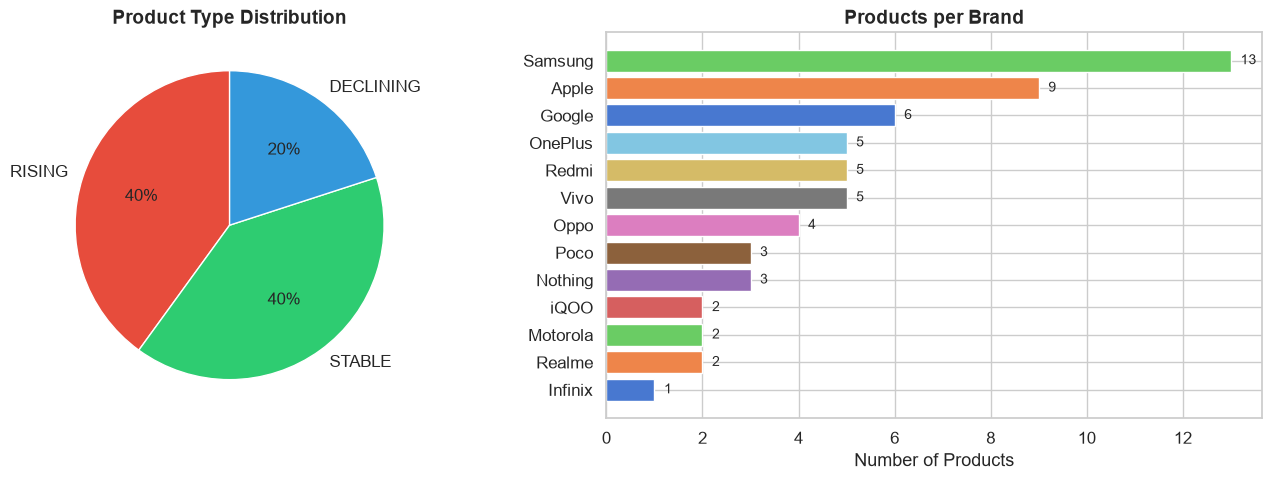

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

type_counts = products['product_type'].value_counts()
colors_type = {'RISING': '#e74c3c', 'STABLE': '#2ecc71', 'DECLINING': '#3498db'}
axes[0].pie(type_counts.values, labels=type_counts.index, autopct='%1.0f%%',
            colors=[colors_type.get(t, '#95a5a6') for t in type_counts.index],
            startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Product Type Distribution', fontsize=14, fontweight='bold')

brand_counts = products['brand'].value_counts()
bars = axes[1].barh(brand_counts.index[::-1], brand_counts.values[::-1],
                    color=sns.color_palette('muted', len(brand_counts)))
axes[1].set_xlabel('Number of Products')
axes[1].set_title('Products per Brand', fontsize=14, fontweight='bold')
for bar in bars:
    w = bar.get_width()
    axes[1].text(w + 0.2, bar.get_y() + bar.get_height()/2, f'{int(w)}',
                ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 3. Brand x Product Type Heatmap

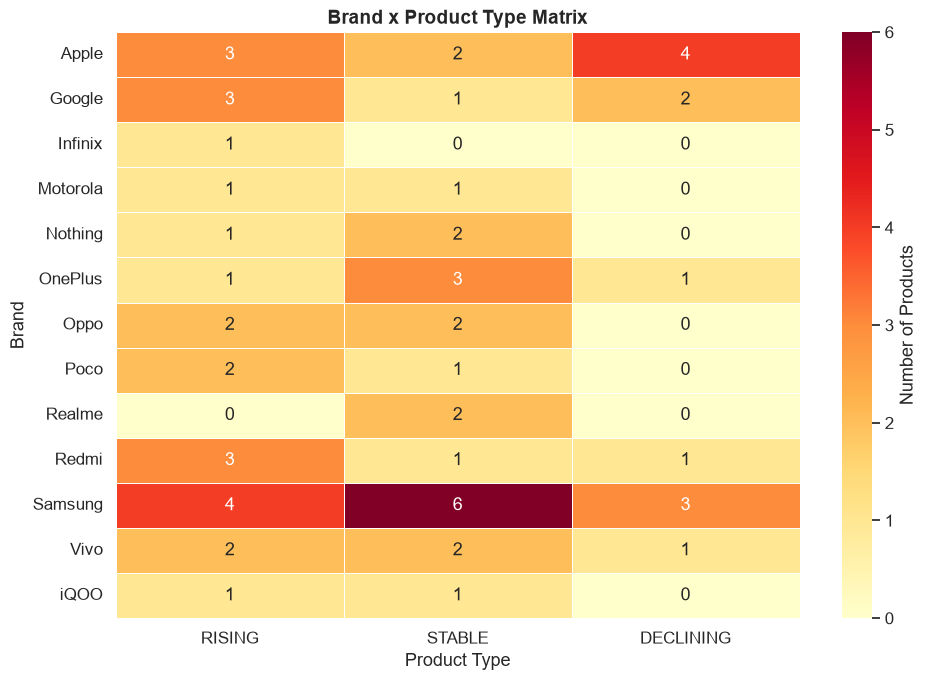

In [5]:
brand_type = pd.crosstab(products['brand'], products['product_type'])
for col in ['RISING', 'STABLE', 'DECLINING']:
    if col not in brand_type.columns:
        brand_type[col] = 0
brand_type = brand_type[['RISING', 'STABLE', 'DECLINING']]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(brand_type, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Number of Products'}, ax=ax)
ax.set_title('Brand x Product Type Matrix', fontsize=14, fontweight='bold')
ax.set_ylabel('Brand')
ax.set_xlabel('Product Type')
plt.tight_layout()
plt.show()

## 4. Launch Timeline

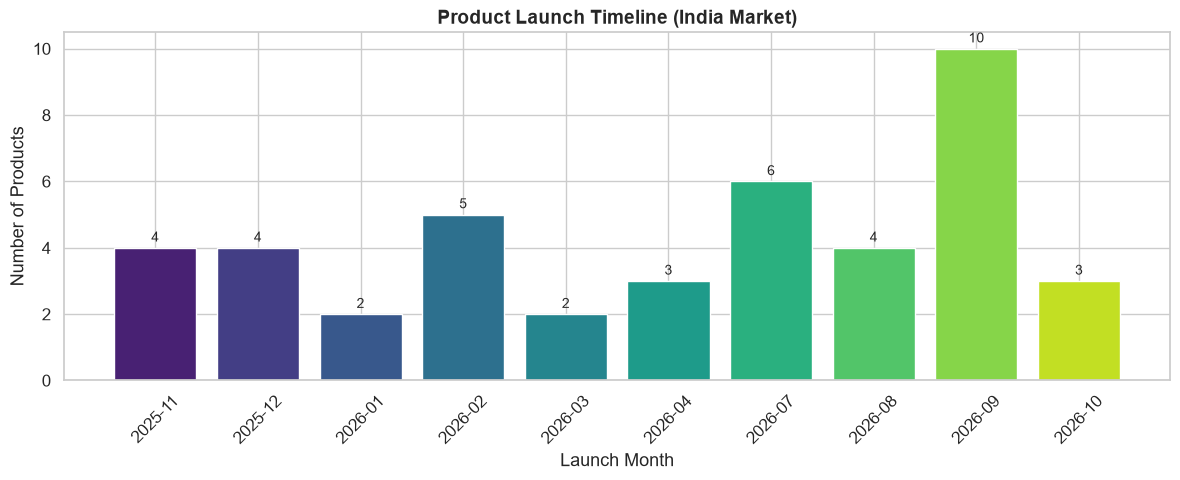

In [6]:
launch_data = products[~products['launch_period'].isin(['established', 'unverified'])].copy()
launch_counts = launch_data['launch_period'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(launch_counts.index, launch_counts.values,
              color=sns.color_palette('viridis', len(launch_counts)))
ax.set_xlabel('Launch Month')
ax.set_ylabel('Number of Products')
ax.set_title('Product Launch Timeline (India Market)', fontsize=14, fontweight='bold')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.xticks(rotation=45)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.1, f'{int(h)}',
            ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 5. Data Sources Documentation

In [7]:
source_log = pd.read_csv(os.path.join(DATA_DIR, 'source_log.csv'))
print(f'Data sources documented: {len(source_log)}')
print()
for i, row in source_log.iterrows():
    print(f'Source {i+1}: {row["source"]}')
    print(f'  Access: {str(row["access_method"])[:100]}...')
    print(f'  Granularity: {row["granularity"]}')
    print(f'  Added: {row["added_date"]}')
    print()

Data sources documented: 5

Source 1: YouTube Data API v3
  Access: Official REST API with an API key (src/collect_youtube.py); search.list then videos.list then commen...
  Granularity: daily snapshot per product (counts are cumulative at collection time)
  Added: 2026-10-03

Source 2: Google Trends
  Access: Manual CSV export from trends.google.com (Interest over time), saved untouched to raw/trends/ and pa...
  Granularity: weekly for a 12-month window (daily for windows of 90 days or less)
  Added: 2026-10-03

Source 3: Google Trends
  Access: Manual CSV export from trends.google.com (Interest over time) with a custom time range, saved untouc...
  Granularity: daily; window changed on 2026-10-03 from 12 months weekly to a 269-day custom range (about 9 months), identical for every product; supersedes the earlier Google Trends row
  Added: 2026-10-03

Source 4: YouTube Data API v3
  Access: Official REST API with an API key (src/collect_youtube.py). Main pass: search.list (order=rele

## 6. Collection Log Summary

In [8]:
collection_log = pd.read_csv(os.path.join(DATA_DIR, 'collection_log.csv'))
print(f'Total collection runs: {len(collection_log)}')
print(f'All successful: {(collection_log["status"].isin(["success", "smoke_test_ok"])).all()}')
print()

summary = collection_log.groupby('source').agg(
    runs=('status', 'count'),
    total_records=('records_collected', 'sum'),
    total_quota=('quota_units', 'sum')
).reset_index()
print(summary.to_string(index=False))
print()

collected = collection_log[collection_log['status'] == 'success']['product_id'].unique()
print(f'Pilot products with YouTube data: {len(collected)}')
print(f'IDs: {sorted(collected)}')

Total collection runs: 412
All successful: False

                source  runs  total_records  total_quota
         google_trends    70          18830            0
google_trends_pytrends   194          16140            0
               youtube    78          36822          505
        youtube_recent    70           3146           70

Pilot products with YouTube data: 60
IDs: ['P001', 'P002', 'P003', 'P004', 'P005', 'P006', 'P007', 'P008', 'P009', 'P010', 'P011', 'P012', 'P013', 'P014', 'P015', 'P016', 'P017', 'P018', 'P019', 'P020', 'P021', 'P022', 'P023', 'P024', 'P025', 'P026', 'P027', 'P028', 'P029', 'P030', 'P031', 'P032', 'P033', 'P034', 'P035', 'P036', 'P037', 'P038', 'P039', 'P040', 'P041', 'P042', 'P043', 'P044', 'P045', 'P046', 'P047', 'P048', 'P049', 'P050', 'P051', 'P052', 'P053', 'P054', 'P055', 'P056', 'P057', 'P058', 'P059', 'P060']


In [9]:
print('\n=== SCRUM-5 COMPLETE ===')
print('Product registry: 60 smartphones documented')
print('Data sources: YouTube Data API v3 + Google Trends (manual export)')
print('Collection: 10 pilot products collected successfully')


=== SCRUM-5 COMPLETE ===
Product registry: 60 smartphones documented
Data sources: YouTube Data API v3 + Google Trends (manual export)
Collection: 10 pilot products collected successfully
